In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [17]:
foods = pd.read_csv('../data/processed/foods_cleaned.csv')

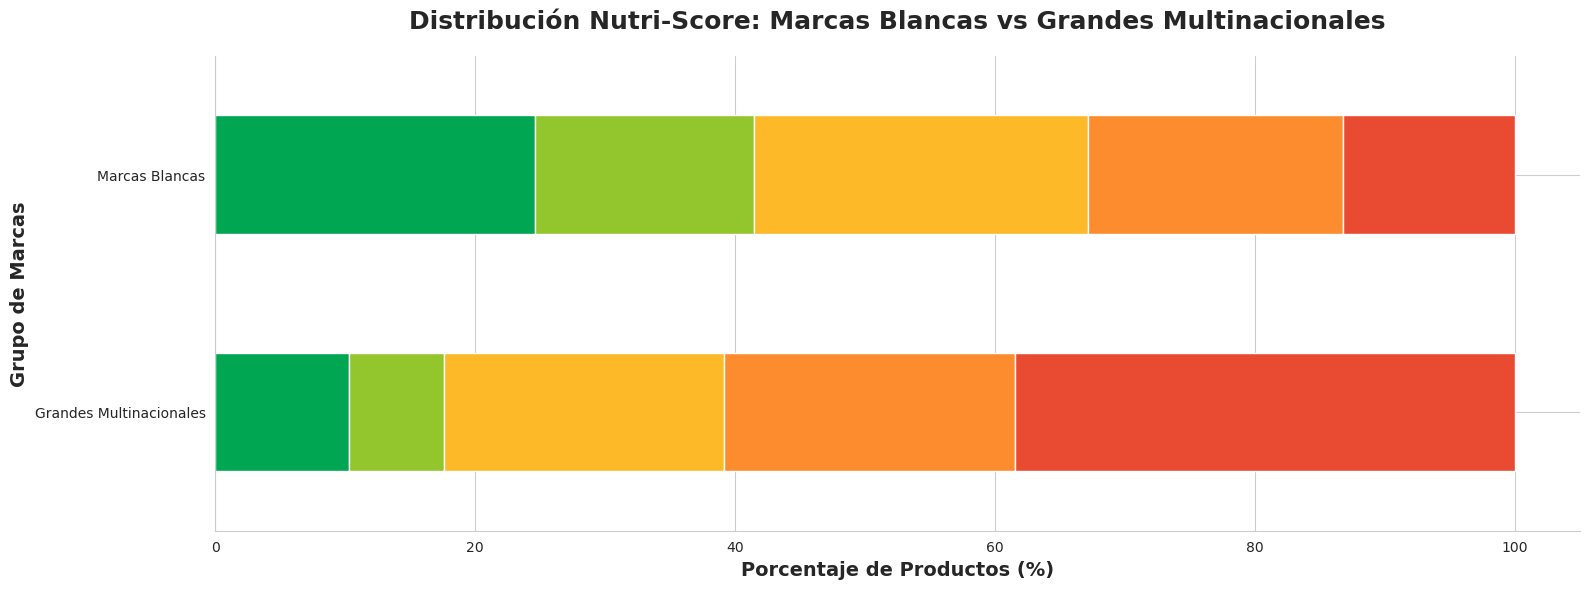

Productos válidos (sin not-applicable/unknown):
grupo
Marcas Blancas             1141
Grandes Multinacionales     738
Name: count, dtype: int64

Distribución %:
nutriscore_grade            a     b     c     d     e
grupo                                                
Grandes Multinacionales  10.3   7.3  21.5  22.4  38.5
Marcas Blancas           24.6  16.8  25.7  19.6  13.2


In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Listas de grupos
marcas_blancas = [
    'hacendado', 'mercadona', 'deliplus', 'compy', 'bosque verde', 'entrepinares', 
    'lidl', 'alesto', 'milbona', 'fin carré', 'sondey', 'freshona', 'crownfield', 
    'carrefour', 'u bio', 'paturages', 'nos regions ont du talent',
    'bio village', 'marque repère',
    'aldi', 'harvest morn', 'village bakery',
    'tesco', 'auchan', 'intermarche'
]

grandes_multinacionales = [
    'nestle', 'nescafe', 'unilever', 'hellmann', 'knorr', 'mondelez', 'lu', 'milka', 
    'danone', 'activia', 'ferrero', 'nutella', 'pepsico', 'lays', 'coca-cola', 
    'kellogg', 'pringles', 'heinz', 'mars', 'dr. oetker'
]

# 2. Clasificar
foods['brands_clean'] = foods['brands'].fillna('').astype(str).str.lower()
def clasificar_grupo(brand):
    brands_list = brand.split()
    for b in brands_list:
        if any(mb in b for mb in marcas_blancas):
            return 'Marcas Blancas'
        if any(multi in b for multi in grandes_multinacionales):
            return 'Grandes Multinacionales'
    return 'Otras'

foods['grupo'] = foods['brands_clean'].apply(clasificar_grupo)

# 3. Filtrar: QUITAR not-applicable, unknown + datos válidos
df_plot = foods[
    (foods['nutriscore_grade'].notna()) &
    (foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])) & 
    (foods['grupo'].isin(['Marcas Blancas', 'Grandes Multinacionales']))
].copy()

# 4. % distribución
nutri_dist = df_plot.groupby(['grupo', 'nutriscore_grade']).size().unstack(fill_value=0)
nutri_pct = nutri_dist.div(nutri_dist.sum(axis=1), axis=0) * 100

# 5. BAR PLOT
# Aumentamos el ancho (16) y ajustamos el alto (6)
plt.figure(figsize=(16, 6))
sns.set_style("whitegrid")

colors_nutri = {'a': '#00A651', 'b': '#93C52D', 'c': '#FDB927', 'd': '#FD8C2E', 'e': '#E94B32'}
nutri_order = ['a', 'b', 'c', 'd', 'e']

# Graficamos sin generar la leyenda automáticamente
ax = nutri_pct[nutri_order].plot(kind='barh', stacked=True, color=[colors_nutri[col] for col in nutri_order], ax=plt.gca())

plt.title("Distribución Nutri-Score: Marcas Blancas vs Grandes Multinacionales", 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Porcentaje de Productos (%)", fontsize=14, fontweight='bold')
plt.ylabel("Grupo de Marcas", fontsize=14, fontweight='bold')

# Eliminamos la leyenda
plt.gca().get_legend().remove()

plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.show()

# Resumen
print("Productos válidos (sin not-applicable/unknown):")
print(df_plot['grupo'].value_counts())
print("\nDistribución %:")
print(nutri_pct.round(1))

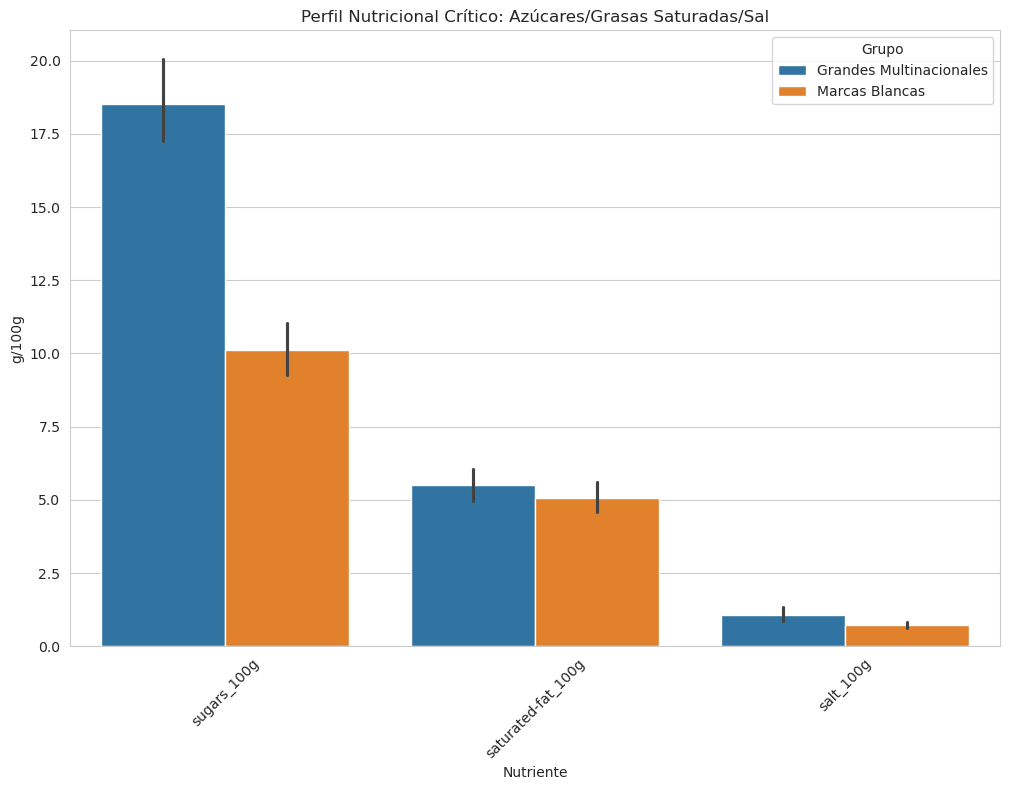

In [19]:
nutri_cols = ['sugars_100g', 'saturated-fat_100g', 'salt_100g']
df_melt = df_plot.melt(id_vars='grupo', value_vars=nutri_cols, 
                       var_name='Nutriente', value_name='g_100g')

plt.figure(figsize=(12, 8))
sns.barplot(data=df_melt, x='Nutriente', y='g_100g', hue='grupo')
plt.title("Perfil Nutricional Crítico: Azúcares/Grasas Saturadas/Sal")
plt.ylabel("g/100g")
plt.xticks(rotation=45)
plt.legend(title="Grupo")
plt.show()

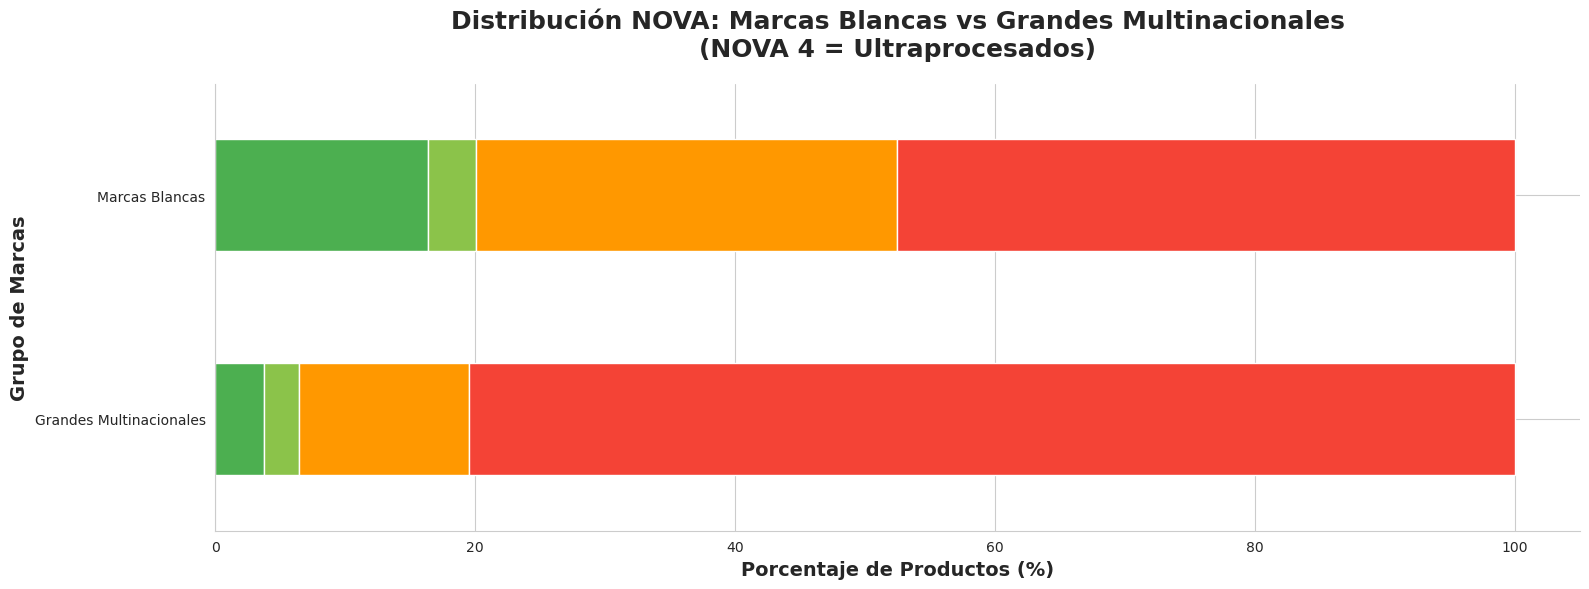

Distribución NOVA (%):
nova_group               nova_group_1  nova_group_2  nova_group_3  \
grupo                                                               
Grandes Multinacionales           3.8           2.6          13.1   
Marcas Blancas                   16.4           3.7          32.4   

nova_group               nova_group_4  
grupo                                  
Grandes Multinacionales          80.5  
Marcas Blancas                   47.5  


In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Clasificación de grupos (reutilizando tu lógica)
foods['brands_clean'] = foods['brands'].fillna('').astype(str).str.lower()

def clasificar_grupo(brand):
    brands_list = brand.split()
    for b in brands_list:
        if any(mb in b for mb in marcas_blancas):
            return 'Marcas Blancas'
        if any(multi in b for multi in grandes_multinacionales):
            return 'Grandes Multinacionales'
    return 'Otras'

foods['grupo'] = foods['brands_clean'].apply(clasificar_grupo)

# 2. Filtrado de valores NOVA válidos (1-4) y grupos de interés
df_plot = foods[
    (foods['nova_group'].between(1, 4)) & 
    (foods['grupo'].isin(['Marcas Blancas', 'Grandes Multinacionales']))
].copy()

df_plot['nova_group'] = 'nova_group_' + df_plot['nova_group'].astype(str)

# 3. Calcular % distribución NOVA
dist_nova = df_plot.groupby(['grupo', 'nova_group']).size().unstack(fill_value=0)
dist_pct = dist_nova.div(dist_nova.sum(axis=1), axis=0) * 100

# Asegurar orden NOVA 1-4
for i in range(1, 5):
    col = f'nova_group_{i}'
    if col not in dist_pct.columns:
        dist_pct[col] = 0
dist_pct = dist_pct[[f'nova_group_{i}' for i in range(1, 5)]]

# 4. GRÁFICO: Distribución NOVA
# Ajustamos a un formato más ancho (16x6)
plt.figure(figsize=(16, 6))
sns.set_style("whitegrid")

# Colores estándar para NOVA (Verde a Rojo)
colors_nova = {'nova_group_1': '#4CAF50', 'nova_group_2': '#8BC34A', 
               'nova_group_3': '#FF9800', 'nova_group_4': '#F44336'}

# Graficamos
ax = dist_pct.plot(kind='barh', stacked=True, 
                   color=[colors_nova.get(col, '#9E9E9E') for col in dist_pct.columns],
                   ax=plt.gca())

plt.title("Distribución NOVA: Marcas Blancas vs Grandes Multinacionales\n(NOVA 4 = Ultraprocesados)", 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Porcentaje de Productos (%)", fontsize=14, fontweight='bold')
plt.ylabel("Grupo de Marcas", fontsize=14, fontweight='bold')

# Eliminamos la leyenda
if plt.gca().get_legend():
    plt.gca().get_legend().remove()

plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.show()

# Resumen rápido por consola
print("Distribución NOVA (%):")
print(dist_pct.round(1))

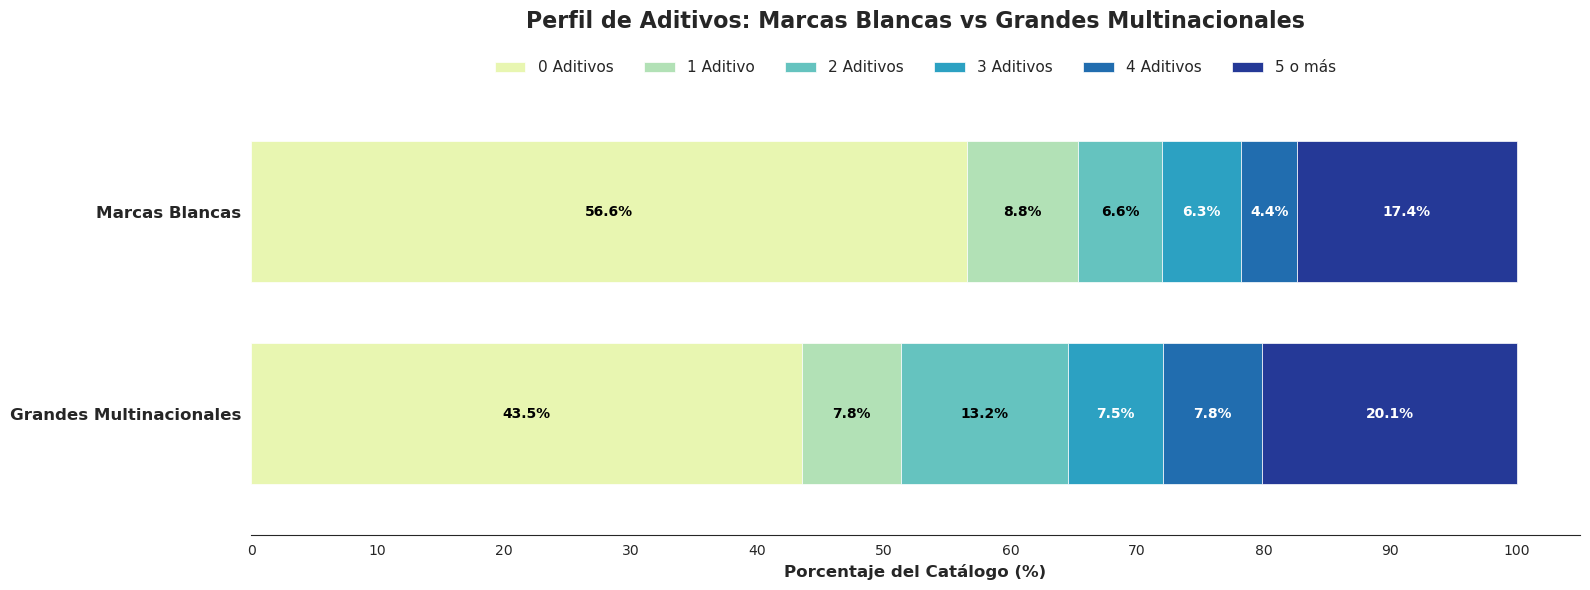

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Clasificación (Se mantiene tu lógica)
marcas_blancas = [
    'hacendado', 'mercadona', 'deliplus', 'compy', 'bosque verde', 'entrepinares', 
    'lidl', 'alesto', 'milbona', 'fin carré', 'sondey', 'freshona', 'crownfield', 
    'carrefour', 'u bio', 'paturages', 'nos regions ont du talent',
    'bio village', 'marque repère', 'aldi', 'harvest morn', 'village bakery',
    'tesco', 'auchan', 'intermarche'
]

grandes_multinacionales = [
    'nestle', 'nescafe', 'unilever', 'hellmann', 'knorr', 'mondelez', 'lu', 'milka', 
    'danone', 'activia', 'ferrero', 'nutella', 'pepsico', 'lays', 'coca-cola', 
    'kellogg', 'pringles', 'heinz', 'mars', 'dr. oetker'
]

foods['brands_clean'] = foods['brands'].fillna('').astype(str).str.lower()
def clasificar_grupo(brand):
    brands_list = brand.split()
    for b in brands_list:
        if any(mb in b for mb in marcas_blancas): return 'Marcas Blancas'
        if any(multi in b for multi in grandes_multinacionales): return 'Grandes Multinacionales'
    return 'Otras'

foods['grupo'] = foods['brands_clean'].apply(clasificar_grupo)

# 2. Categorías de conteo de aditivos
def agrupar_aditivos(c):
    if c == 0: return '0 Aditivos'
    if c == 1: return '1 Aditivo'
    if c == 2: return '2 Aditivos'
    if c == 3: return '3 Aditivos'
    if c == 4: return '4 Aditivos'
    return '5 o más'

df_plot = foods[foods['grupo'].isin(['Marcas Blancas', 'Grandes Multinacionales'])].copy()
df_plot['additive_cat'] = df_plot['additive_count'].apply(agrupar_aditivos)

# 3. Preparación de datos (100% Stacked)
cat_order = ['0 Aditivos', '1 Aditivo', '2 Aditivos', '3 Aditivos', '4 Aditivos', '5 o más']
counts = df_plot.groupby(['grupo', 'additive_cat']).size().unstack(fill_value=0)[cat_order]
pct_dist = counts.div(counts.sum(axis=1), axis=0) * 100

# 4. Configuración del Gráfico
plt.figure(figsize=(16, 6)) # Un poco más alto para dar aire a la leyenda
sns.set_style("white")

# Usamos la paleta que prefieras (ej: YlGnBu o viridis para visibilidad)
colors = sns.color_palette("YlGnBu", n_colors=len(cat_order))

ax = pct_dist.plot(
    kind='barh', 
    stacked=True, 
    color=colors, 
    ax=plt.gca(),
    width=0.7,
    edgecolor='white',
    linewidth=0.5
)

# 5. Anotaciones de porcentaje
for i, (grupo, row_pct) in enumerate(pct_dist.iterrows()):
    cum_width = 0
    for j, cat in enumerate(cat_order):
        width = row_pct[cat]
        if width > 3: 
            x_pos = cum_width + width / 2
            text_color = "black" if j < 3 else "white"
            ax.text(x_pos, i, f'{width:.1f}%', ha='center', va='center', 
                    color=text_color, fontweight='bold', fontsize=10)
        cum_width += width

# --- NUEVA LEYENDA CONFIGURADA ---
plt.legend(
    title=" ",
    title_fontsize='12',
    bbox_to_anchor=(0.5, 1.15), 
    loc='upper center', 
    ncol=len(cat_order),        
    frameon=False,              
    fontsize=11
)

# Estética
plt.title("Perfil de Aditivos: Marcas Blancas vs Grandes Multinacionales", 
          fontsize=16, fontweight='bold', pad=45) # Más 'pad' para que no choque con la leyenda
plt.xlabel("Porcentaje del Catálogo (%)", fontsize=12, fontweight='bold')
plt.ylabel("")
plt.xticks(range(0, 101, 10))
plt.yticks(fontsize=12, fontweight='bold')

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

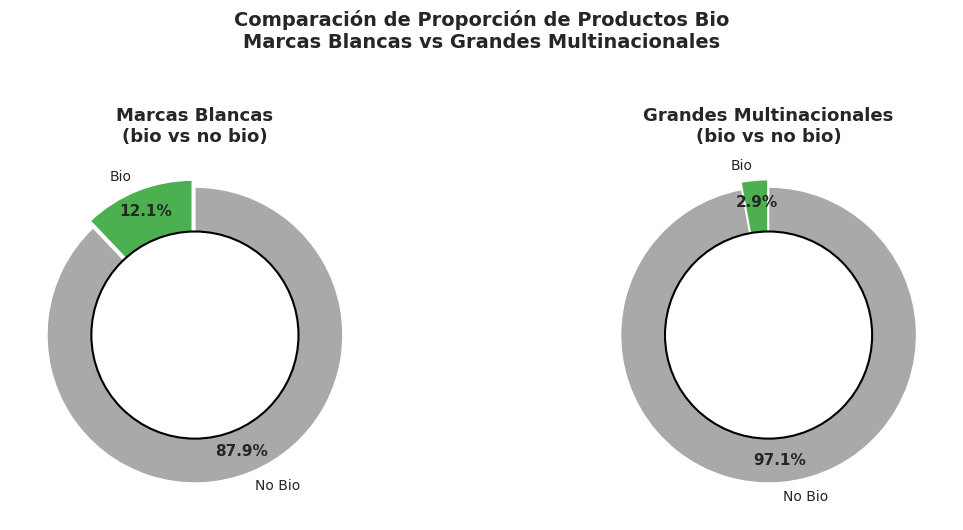

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Clasificación grupos (mismo diccionario)
marcas_blancas = ['hacendado', 'mercadona', 'deliplus', 'compy', 'bosque verde', 
                  'entrepinares', 'lidl', 'alesto', 'milbona', 'fin carré', 'sondey', 
                  'freshona', 'crownfield', 'carrefour', 'u bio', 'paturages', 
                  'nos regions ont du talent', 'bio village', 'marque repère', 
                  'aldi', 'harvest morn', 'village bakery', 'tesco', 'auchan', 'intermarche']

grandes_multinacionales = ['nestle', 'nescafe', 'unilever', 'hellmann', 'knorr', 
                           'mondelez', 'lu', 'milka', 'danone', 'activia', 'ferrero', 
                           'nutella', 'pepsico', 'lays', 'coca-cola', 'kellogg', 
                           'pringles', 'heinz', 'mars', 'dr. oetker']

foods['brands_clean'] = foods['brands'].fillna('').astype(str).str.lower()

def clasificar_grupo(brand):
    brands_list = brand.split()
    for b in brands_list:
        if any(mb in b for mb in marcas_blancas):
            return 'Marcas Blancas'
        if any(multi in b for multi in grandes_multinacionales):
            return 'Grandes Multinacionales'
    return 'Otras'

foods['grupo'] = foods['brands_clean'].apply(clasificar_grupo)

# Filtrar solo los dos grupos de interés
df_bio = foods[foods['grupo'].isin(['Marcas Blancas', 'Grandes Multinacionales'])].copy()

# GRÁFICO DE ANILLO (DONUT) - Solo para comparar proporciones de bio
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, grupo in zip(axes, ['Marcas Blancas', 'Grandes Multinacionales']):
    datos_grupo = df_bio[df_bio['grupo'] == grupo]['is_bio'].value_counts()
    bio_count = datos_grupo.get(True, 0)
    no_bio_count = datos_grupo.get(False, 0)
    
    sizes = [bio_count, no_bio_count]
    labels = ['Bio', 'No Bio']
    colors_donut = ['#4CAF50', '#A9A9A9']
    explode = (0.05, 0)
    
    wedges, texts, autotexts = ax.pie(sizes, explode=explode, labels=labels, colors=colors_donut,
                                        autopct='%1.1f%%', startangle=90, pctdistance=0.85)
    
    # Convertir a donut
    centre_circle = plt.Circle((0,0), 0.70, fc='white', linewidth=1.5, edgecolor='black')
    ax.add_artist(centre_circle)
    
    ax.set_title(f'{grupo}\n(bio vs no bio)', fontsize=13, fontweight='bold')
    
    # Aumentar tamaño de texto
    for autotext in autotexts:
        autotext.set_fontsize(11)
        autotext.set_fontweight('bold')
    for text in texts:
        text.set_fontsize(10)

plt.suptitle('Comparación de Proporción de Productos Bio\nMarcas Blancas vs Grandes Multinacionales', 
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()



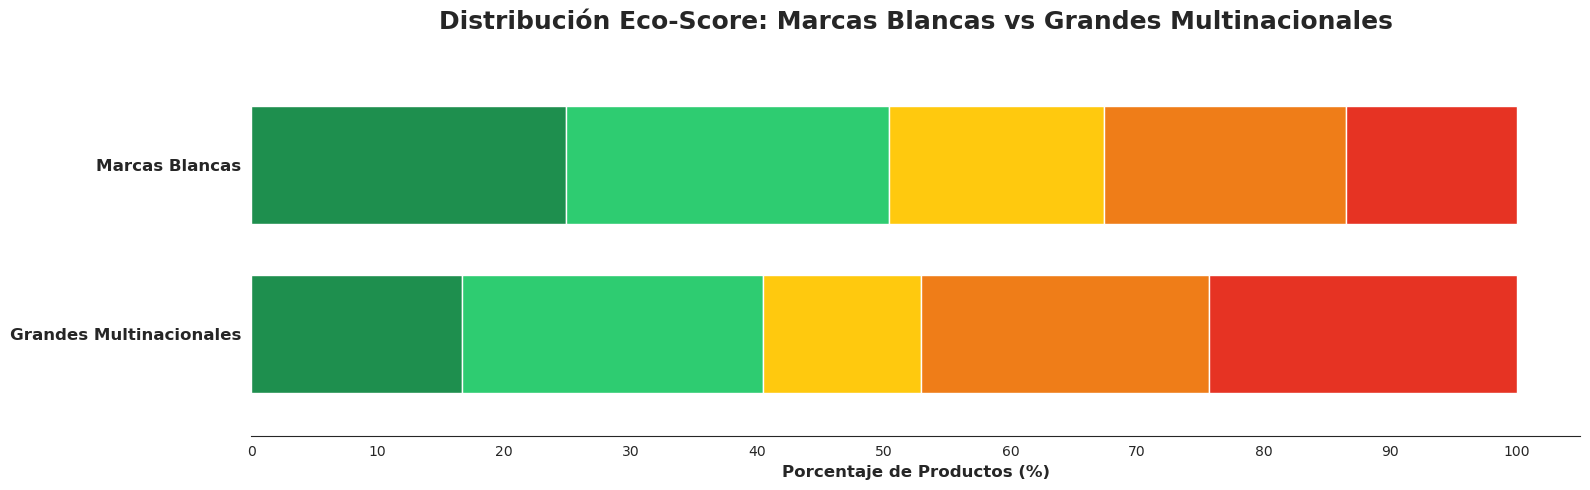

Distribución Eco-Score (%):
ecoscore_grade              a     b     c     d     e
grupo                                                
Grandes Multinacionales  16.7  23.8  12.5  22.7  24.3
Marcas Blancas           24.9  25.5  17.0  19.1  13.5


In [42]:
marcas_blancas = [
    'hacendado', 'mercadona', 'deliplus', 'compy', 'bosque verde', 'entrepinares', 
    'lidl', 'alesto', 'milbona', 'fin carré', 'sondey', 'freshona', 'crownfield', 
    'carrefour', 'u bio', 'paturages', 'nos regions ont du talent',
    'bio village', 'marque repère', 'aldi', 'harvest morn', 'village bakery',
    'tesco', 'auchan', 'intermarche'
]

grandes_multinacionales = [
    'nestle', 'nescafe', 'unilever', 'hellmann', 'knorr', 'mondelez', 'lu', 'milka', 
    'danone', 'activia', 'ferrero', 'nutella', 'pepsico', 'lays', 'coca-cola', 
    'kellogg', 'pringles', 'heinz', 'mars', 'dr. oetker'
]

foods['brands_clean'] = foods['brands'].fillna('').astype(str).str.lower()
def clasificar_grupo(brand):
    brands_list = brand.split()
    for b in brands_list:
        if any(mb in b for mb in marcas_blancas): return 'Marcas Blancas'
        if any(multi in b for multi in grandes_multinacionales): return 'Grandes Multinacionales'
    return 'Otras'

foods['grupo'] = foods['brands_clean'].apply(clasificar_grupo)

# 2. Filtrado de Eco-Score (A-E)
eco_order = ['a', 'b', 'c', 'd', 'e']
df_plot = foods[
    (foods['ecoscore_grade'].notna()) &
    (foods['ecoscore_grade'].str.lower().isin(eco_order)) &
    (foods['grupo'].isin(['Marcas Blancas', 'Grandes Multinacionales']))
].copy()

# 3. Cálculo de distribución porcentual
eco_dist = df_plot.groupby(['grupo', 'ecoscore_grade']).size().unstack(fill_value=0)
# Asegurar que todas las columnas existan
for col in eco_order:
    if col not in eco_dist.columns:
        eco_dist[col] = 0

# Reordenar y normalizar al 100%
eco_pct = eco_dist[eco_order].div(eco_dist.sum(axis=1), axis=0) * 100

# 4. BAR PLOT (Estilo Nutri-Score: Ancho y sin leyenda)
plt.figure(figsize=(16, 5))
sns.set_style("white")

# Colores oficiales Eco-Score
colors_eco = {'a': '#1E8F4E', 'b': '#2ECC71', 'c': '#FFC90E', 'd': '#EF7D18', 'e': '#E63323'}

ax = eco_pct.plot(
    kind='barh', 
    stacked=True, 
    color=[colors_eco[col] for col in eco_order],
    ax=plt.gca(),
    width=0.7,
    edgecolor='white',
    linewidth=1
)

# Estética y Títulos
plt.title("Distribución Eco-Score: Marcas Blancas vs Grandes Multinacionales", 
          fontsize=18, fontweight='bold', pad=25)
plt.xlabel("Porcentaje de Productos (%)", fontsize=12, fontweight='bold')
plt.ylabel("")
plt.xticks(range(0, 101, 10))
plt.yticks(fontsize=12, fontweight='bold')

# Eliminar leyenda
if plt.gca().get_legend():
    plt.gca().get_legend().remove()

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

# Resumen rápido por consola
print("Distribución Eco-Score (%):")
print(eco_pct.round(1))

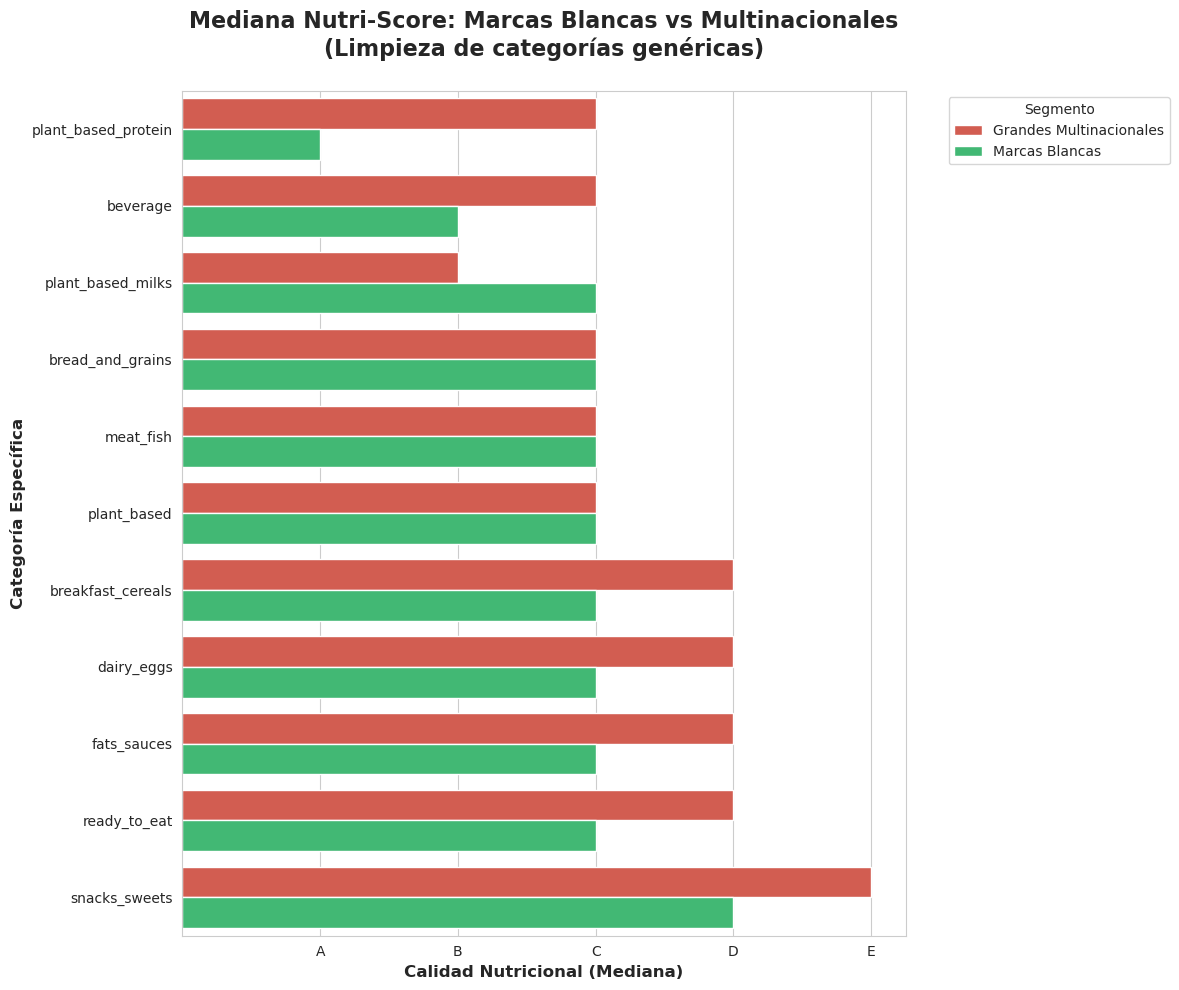

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Mapeo de Nutri-Score
mapping = {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5}

# 2. Filtrado Exhaustivo
# - Solo grados válidos (A-E)
# - Solo los dos grupos de interés (excluye el grupo 'Otras')
# - EXCLUIMOS la categoría 'otros' del eje vertical (category_unified)
palabras_a_excluir = ['otros']

df_filtered = foods[
    (foods['nutriscore_grade'].notna()) & 
    (foods['nutriscore_grade'].str.lower().isin(['a', 'b', 'c', 'd', 'e'])) &
    (foods['grupo'].isin(['Marcas Blancas', 'Grandes Multinacionales'])) &
    (~foods['category_unified'].str.lower().str.contains('|'.join(palabras_a_excluir)))
].copy()

# 3. Transformación numérica
df_filtered['nutri_num'] = df_filtered['nutriscore_grade'].str.lower().map(mapping)

# 4. Cálculo de la mediana por categoría y grupo
medianas = df_filtered.groupby(['category_unified', 'grupo'])['nutri_num'].median().reset_index()

# 5. Ordenamos las categorías (por el promedio de sus medianas) para el gráfico
orden_cats = medianas.groupby('category_unified')['nutri_num'].mean().sort_values().index

# 6. Gráfico
plt.figure(figsize=(12, 10))
sns.set_style("whitegrid")

sns.barplot(
    data=medianas, 
    y='category_unified', 
    x='nutri_num', 
    hue='grupo',
    order=orden_cats,
    palette={'Marcas Blancas': '#2ecc71', 'Grandes Multinacionales': '#e74c3c'}
)

# Sustituimos números por letras en el eje X
plt.xticks(ticks=[1, 2, 3, 4, 5], labels=['A', 'B', 'C', 'D', 'E'])

plt.title("Mediana Nutri-Score: Marcas Blancas vs Multinacionales\n(Limpieza de categorías genéricas)", 
          fontsize=16, fontweight='bold', pad=25)
plt.xlabel("Calidad Nutricional (Mediana)", fontsize=12, fontweight='bold')
plt.ylabel("Categoría Específica", fontsize=12, fontweight='bold')
plt.legend(title="Segmento", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

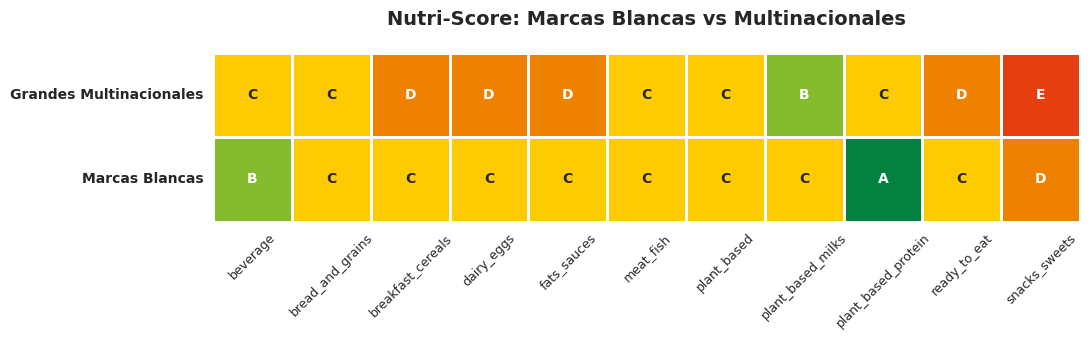

In [30]:

# 1. Colores oficiales Nutri-Score y Mapeos
colores_nutri = ['#038141', '#85bb2f', '#fecb02', '#ee8100', '#e63e11']
cmap_nutri = ListedColormap(colores_nutri)

mapping_num = {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5}
mapping_letra = {1: 'A', 2: 'B', 3: 'C', 4: 'D', 5: 'E'}

# 2. Filtrado (sin "Otros")
df_heat = foods[
    (foods['nutriscore_grade'].notna()) & 
    (foods['nutriscore_grade'].str.lower().isin(['a', 'b', 'c', 'd', 'e'])) &
    (foods['grupo'].isin(['Marcas Blancas', 'Grandes Multinacionales']))
].copy()

df_heat['nutri_num'] = df_heat['nutriscore_grade'].str.lower().map(mapping_num)

# 3. Matriz para el Heatmap
heatmap_data = df_heat.pivot_table(
    index='grupo', 
    columns='category_unified', 
    values='nutri_num', 
    aggfunc='median'
)

# Etiquetas A-E
annot_labels = heatmap_data.round().replace(mapping_letra).values

# 4. Gráfico con proporciones equilibradas
# Aumentamos un poco el figsize para que no se vea "aplastado"
# n_categorias * 0.6 suele dar un ancho de celda compacto pero estético
plt.figure(figsize=(len(heatmap_data.columns) * 1, 3.5)) 

sns.heatmap(
    heatmap_data, 
    annot=annot_labels,      
    fmt="",                  
    cmap=cmap_nutri,         
    linewidths=2,            # Líneas más gruesas para separar mejor los cuadros
    linecolor='white',
    cbar=False,              
    vmin=0.5, vmax=5.5,      
    annot_kws={"weight": "bold", "size": 10} # Letra de la A-E un poco más pequeña
)

# Estética y ajuste de fuentes
plt.title("Nutri-Score: Marcas Blancas vs Multinacionales", 
          fontsize=14, fontweight='bold', pad=20)

plt.xlabel("", fontsize=1) # Ocultamos el título del eje X para ganar espacio
plt.ylabel("", fontsize=1) # Ocultamos el título del eje Y

# Ajustamos el tamaño de letra de las categorías (eje X) y grupos (eje Y)
plt.xticks(rotation=45, fontsize=9) 
plt.yticks(rotation=0, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()